In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
from imblearn.over`_sampling import SMOTE

# 1. Generate Synthetic Credit Data
np.random.seed(42)
n_samples = 1000

data = {
    'Income': np.random.randint(20000, 150000, n_samples),
    'Existing_Debts': np.random.randint(0, 50000, n_samples),
    'Loan_History_Months': np.random.randint(6, 72, n_samples),
    'Missed_Payments': np.random.randint(0, 10, n_samples),
    'Credit_Utilization_Rate': np.random.uniform(0.1, 0.95, n_samples),
    'Account_Balance': np.random.randint(-5000, 100000, n_samples)
}

df = pd.DataFrame(data)

# 2. Define a rule-based engine to create our multi-class target: Low, Medium, High Risk
def assign_risk(row):
    score = (row['Missed_Payments'] * 15) + (row['Credit_Utilization_Rate'] * 50) + (row['Existing_Debts'] / row['Income'] * 30) - (row['Account_Balance'] / 10000)
    if score > 60:
        return 'High Risk'
    elif score > 30:
        return 'Medium Risk'
    else:

        return 'Low Risk'

df['Risk_Rating'] = df.apply(assign_risk, axis=1)
print("Dataset Sample:")
print(df.head())
print("\nTarget Class Distribution:\n", df['Risk_Rating'].value_counts())

Dataset Sample:
   Income  Existing_Debts  Loan_History_Months  Missed_Payments  \
0  141958           13216                   18                0   
1   35795           35547                   51                6   
2   20860           31471                   32                4   
3  123694           17308                   22                4   
4  148106           27532                   65                1   

   Credit_Utilization_Rate  Account_Balance  Risk_Rating  
0                 0.730612            28576  Medium Risk  
1                 0.821162            36938    High Risk  
2                 0.459235            44028    High Risk  
3                 0.357491            54807    High Risk  
4                 0.376501            44877  Medium Risk  

Target Class Distribution:
 Risk_Rating
High Risk      765
Medium Risk    177
Low Risk        58
Name: count, dtype: int64


In [2]:
# Separate Features (X) and Target (y)
X = df.drop('Risk_Rating', axis=1)
y = df['Risk_Rating']

# Encode Categorical Target Labels (High Risk=0, Low Risk=1, Medium Risk=2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale the Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balance the dataset classes using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training shape: {X_train_scaled.shape}")
print(f"Resampled training shape: {X_train_resampled.shape}")

Original training shape: (800, 6)
Resampled training shape: (1836, 6)


In [3]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

# Train the model
rf_model.fit(X_train_resampled, y_train_resampled)

# Make Predictions
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled) # Required for ROC-AUC

--- Model Performance Metrics ---
Overall Accuracy: 93.00%

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.97      0.97      0.97       153
    Low Risk       1.00      0.67      0.80        12
 Medium Risk       0.77      0.86      0.81        35

    accuracy                           0.93       200
   macro avg       0.91      0.83      0.86       200
weighted avg       0.93      0.93      0.93       200

ROC-AUC Score (One-vs-Rest): 0.9916


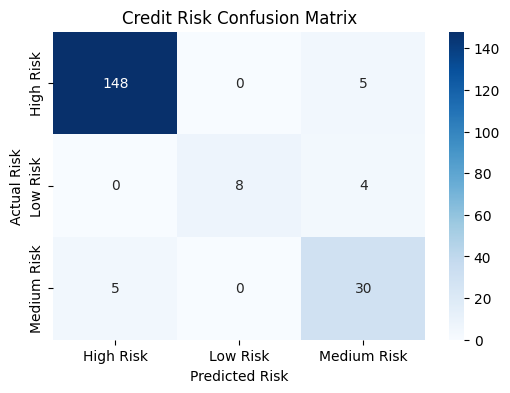

In [4]:
# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Model Performance Metrics ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# 2. Precision, Recall, F1-Score
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 3. Multi-class ROC-AUC Score (using 'ovr' - One-vs-Rest strategy)
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score (One-vs-Rest): {roc_auc:.4f}")

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Credit Risk Confusion Matrix')
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.show()